In [1]:
import pandas as pd
from datetime import datetime
import time

df = pd.read_csv("../data/processed/unsw_nb15_enriched.csv")

In [2]:
def soc_playbook(row):
    severity = row['alert_severity']
    reputation = row['src_reputation']

    if severity == "Critical":
        return "Block_IP"
    
    elif severity == "High":
        return "Isolate_Host"

    elif severity == "Medium":
        return "Alert_Analyst"

    else:
        return "Log_Only"

In [3]:
df['automated_action'] = df.apply(soc_playbook, axis=1)

In [4]:
df['automated_action'].value_counts()

automated_action
Log_Only        8775
Isolate_Host    1225
Name: count, dtype: int64

In [5]:
for i in range(30):
    event = df.iloc[i]

    timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

    print(f"[{timestamp}] SRC={event['srcip']} | "
          f"Severity={event['alert_severity']} | "
          f"Action={event['automated_action']}")

    time.sleep(0.5)

[2026-05-08 10:46:56] SRC=0.3789635232847171 | Severity=Low | Action=Log_Only
[2026-05-08 10:46:56] SRC=0.5468247579076428 | Severity=Low | Action=Log_Only
[2026-05-08 10:46:57] SRC=-1.1317875883216144 | Severity=High | Action=Isolate_Host
[2026-05-08 10:46:57] SRC=0.0432410540388656 | Severity=Low | Action=Log_Only
[2026-05-08 10:46:58] SRC=0.2111022886617914 | Severity=Low | Action=Log_Only
[2026-05-08 10:46:58] SRC=0.3789635232847171 | Severity=Low | Action=Log_Only
[2026-05-08 10:46:59] SRC=-0.12462018058406 | Severity=Low | Action=Log_Only
[2026-05-08 10:46:59] SRC=-0.9639263536986886 | Severity=High | Action=Isolate_Host
[2026-05-08 10:47:00] SRC=1.2182696963993458 | Severity=Low | Action=Log_Only
[2026-05-08 10:47:00] SRC=0.3789635232847171 | Severity=Low | Action=Log_Only
[2026-05-08 10:47:01] SRC=0.0432410540388656 | Severity=Low | Action=Log_Only
[2026-05-08 10:47:01] SRC=0.0432410540388656 | Severity=Low | Action=Log_Only
[2026-05-08 10:47:02] SRC=0.7146859925305685 | Severi

In [6]:
blocked_ips = []

for _, row in df.iterrows():
    if row['automated_action'] == "Block_IP":
        blocked_ips.append(row['srcip'])

In [7]:
set(blocked_ips)

set()

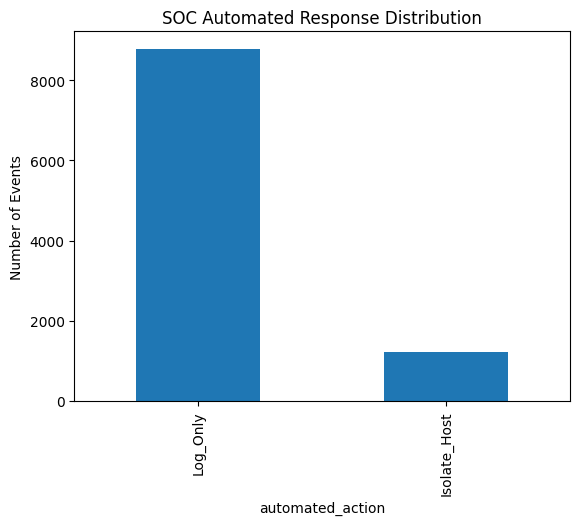

In [8]:
import matplotlib.pyplot as plt

df['automated_action'].value_counts().plot(kind='bar')
plt.title("SOC Automated Response Distribution")
plt.ylabel("Number of Events")
plt.show()

In [9]:
df.to_csv("../data/processed/unsw_nb15_final_soc_output.csv", index=False)